In [1]:
from google.colab import files
uploaded = files.upload()
# Select paysim.csv from your computer

Saving PS_20174392719_1491204439457_log.csv to PS_20174392719_1491204439457_log.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifierfrom sklearn.model_selection
import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

In [3]:
df = pd.read_csv('PS_20174392719_1491204439457_log.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (6362620, 11)

Columns: ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']

First 5 rows:


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
# Data types and nulls
print(df.info())

# Check fraud distribution
print("\nFraud Distribution:")
print(df['isFraud'].value_counts())
print(f"\nFraud Percentage: {df['isFraud'].mean()*100:.2f}%")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB
None

Fraud Distribution:
isFraud
0    6354407
1       8213
Name: count, dtype: int64

Fraud Percentage: 0.13%


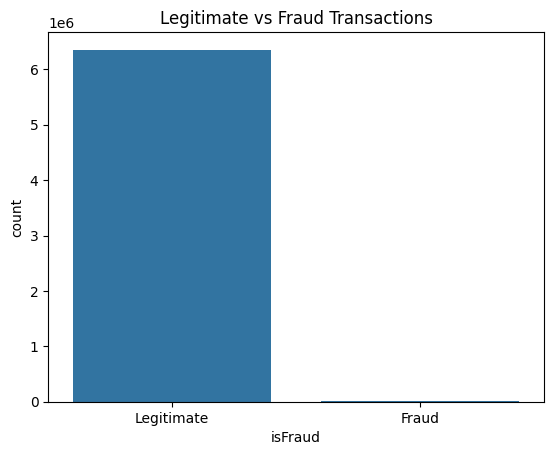

In [5]:
sns.countplot(x='isFraud', data=df)
plt.title('Legitimate vs Fraud Transactions')
plt.xticks([0,1], ['Legitimate', 'Fraud'])
plt.show()

In [6]:
# Check shape before dropping
print("Shape before dropping:", df.shape)

# Drop unnecessary columns
df = df.drop(['nameOrig', 'nameDest', 'isFlaggedFraud'], axis=1)

# Check shape after dropping
print("Shape after dropping:", df.shape)

# Verify columns remaining
print("\nRemaining columns:", df.columns.tolist())

# Check first 5 rows
df.head()

Shape before dropping: (6362620, 11)
Shape after dropping: (6362620, 8)

Remaining columns: ['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud']


,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
0,1,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0
1,1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0
2,1,TRANSFER,181.00,181.0,0.00,0.0,0.0,1
3,1,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1
4,1,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0


In [7]:
# Check what columns exist right now
print(df.columns.tolist())
print("Shape:", df.shape)

['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud']
Shape: (6362620, 8)


In [8]:
# Check which transaction types have fraud
print(df.groupby('type')['isFraud'].sum())
print("\nFraud by type percentage:")
print(df.groupby('type')['isFraud'].mean() * 100)

type
CASH_IN        0
CASH_OUT    4116
DEBIT          0
PAYMENT        0
TRANSFER    4097
Name: isFraud, dtype: int64

Fraud by type percentage:
type
CASH_IN     0.000000
CASH_OUT    0.183955
DEBIT       0.000000
PAYMENT     0.000000
TRANSFER    0.768799
Name: isFraud, dtype: float64


In [9]:
# Check current columns
print("Current columns:", df.columns.tolist())
print("Current shape:", df.shape)

# Convert type to numbers (One Hot Encoding)
df = pd.get_dummies(df, columns=['type'])

print("\nAfter encoding:")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Current columns: ['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud']
Current shape: (6362620, 8)

After encoding:
Shape: (6362620, 12)
Columns: ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.64,170136.0,160296.36,0.0,0.0,0,False,False,False,True,False
1,1,1864.28,21249.0,19384.72,0.0,0.0,0,False,False,False,True,False
2,1,181.00,181.0,0.00,0.0,0.0,1,False,False,False,False,True
3,1,181.00,181.0,0.00,21182.0,0.0,1,False,True,False,False,False
4,1,11668.14,41554.0,29885.86,0.0,0.0,0,False,False,False,True,False


In [10]:
# Convert True/False to 0/1
df = df.astype({col: int for col in df.columns
                if df[col].dtype == bool})

print("Sample after fix:")
df.head()

Sample after fix:


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.64,170136.0,160296.36,0.0,0.0,0,0,0,0,1,0
1,1,1864.28,21249.0,19384.72,0.0,0.0,0,0,0,0,1,0
2,1,181.00,181.0,0.00,0.0,0.0,1,0,0,0,0,1
3,1,181.00,181.0,0.00,21182.0,0.0,1,0,1,0,0,0
4,1,11668.14,41554.0,29885.86,0.0,0.0,0,0,0,0,1,0


In [11]:
# Separate features and target
X = df.drop('isFraud', axis=1)
y = df['isFraud']

# Train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)
print("\nFraud in training:", y_train.sum())
print("Fraud in testing:", y_test.sum())

Training size: (5090096, 11)
Testing size: (1272524, 11)

Fraud in training: 6570
Fraud in testing: 1643


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

lr = LogisticRegression(class_weight='balanced', max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("=== Logistic Regression Results ===")
print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_lr))

=== Logistic Regression Results ===
              precision    recall  f1-score   support

           0       1.00      0.96      0.98   1270881
           1       0.03      0.92      0.06      1643

    accuracy                           0.96   1272524
   macro avg       0.51      0.94      0.52   1272524
weighted avg       1.00      0.96      0.98   1272524

ROC-AUC: 0.9414240556135112


In [13]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(class_weight='balanced',
                             random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("=== Decision Tree Results ===")
print(classification_report(y_test, y_pred_dt))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_dt))

=== Decision Tree Results ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.89      0.87      0.88      1643

    accuracy                           1.00   1272524
   macro avg       0.95      0.94      0.94   1272524
weighted avg       1.00      1.00      1.00   1272524

ROC-AUC: 0.9354150210911604


In [14]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(class_weight='balanced',
                             n_estimators=100,
                             random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("=== Random Forest Results ===")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_rf))

=== Random Forest Results ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.98      0.78      0.87      1643

    accuracy                           1.00   1272524
   macro avg       0.99      0.89      0.94   1272524
weighted avg       1.00      1.00      1.00   1272524

ROC-AUC: 0.8919564737385154


In [15]:
from xgboost import XGBClassifier

# Calculate scale_pos_weight
scale = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale:.2f}")

xgb = XGBClassifier(
    scale_pos_weight=scale,
    n_estimators=100,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print("\n=== XGBoost Results ===")
print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_xgb))

scale_pos_weight: 773.75

=== XGBoost Results ===
              precision    recall  f1-score   support

           0       1.00      0.99      1.00   1270881
           1       0.13      0.99      0.23      1643

    accuracy                           0.99   1272524
   macro avg       0.57      0.99      0.61   1272524
weighted avg       1.00      0.99      0.99   1272524

ROC-AUC: 0.9912160591126792


In [16]:
# Get probability scores
y_prob = xgb.predict_proba(X_test)[:,1]

# Try threshold 0.3
threshold = 0.3
y_pred_threshold = (y_prob >= threshold).astype(int)

print("=== XGBoost With Threshold 0.3 ===")
print(classification_report(y_test, y_pred_threshold))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_threshold))

=== XGBoost With Threshold 0.3 ===
              precision    recall  f1-score   support

           0       1.00      0.99      1.00   1270881
           1       0.12      0.99      0.21      1643

    accuracy                           0.99   1272524
   macro avg       0.56      0.99      0.60   1272524
weighted avg       1.00      0.99      0.99   1272524

ROC-AUC: 0.9912424285974506


In [17]:
import pickle

# Save model
with open('fraud_detection_model.pkl', 'wb') as f:
    pickle.dump(xgb, f)

print("Model saved successfully!")

# Download it
from google.colab import files
files.download('fraud_detection_model.pkl')

Model saved successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:
import json

# Save feature column names
feature_columns = X_train.columns.tolist()

with open('feature_columns.json', 'w') as f:
    json.dump(feature_columns, f)

print("Feature columns saved!")
print("Columns:", feature_columns)

from google.colab import files
files.download('feature_columns.json')

Feature columns saved!
Columns: ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>